# Operations Research — classical algorithms from scratch

Graph algorithms, optimal paths, network flows and linear programming, implemented
from their mathematical definitions in Python. No `networkx`, no `pulp`, no solver
library doing the work behind a one-line call.

Every algorithm is checked against a worked example whose answer was known *before*
the code existed. That makes the assertions in this notebook genuine regression
tests rather than a record of whatever the implementation happened to produce.

**Contents**

1. [Representing a graph](#1) — adjacency, incidence, and the sparse alternative
2. [Connectivity and ranks](#2) — boolean matrix algebra, strong components, layering
3. [Optimal paths](#3) — Dijkstra and Floyd–Warshall
4. [Maximum flow](#4) — Ford–Fulkerson, residual networks, minimum cut
5. [Linear programming](#5) — the simplex on a tableau

Travelling salesman heuristics live in a separate notebook.

**Conventions.** Vertices are 0-indexed internally and 1-indexed on display, so the
output can be compared line by line with a textbook without mental arithmetic.

In [1]:
from collections import deque

import matplotlib.pyplot as plt
import numpy as np

INF = float("inf")

FACE, EDGE, HILITE, TEXT = "#2E6FB7", "#8FA9C4", "#C8452F", "#1B2733"
NODE_R = 0.16
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10})

### A minimal graph container

One class, holding the arcs and their weights. Everything else — matrices, degrees,
traversals — is derived from that, which keeps a single source of truth.

In [2]:
class DiGraph:
    """Directed graph, optionally weighted. Arcs are (i, j) or (i, j, w)."""

    def __init__(self, n, arcs, name=""):
        self.n, self.name = int(n), name
        self.arcs, self.weight = [], {}
        for arc in arcs:
            i, j, w = arc if len(arc) == 3 else (*arc, 1.0)
            self.arcs.append((i, j))
            self.weight[(i, j)] = float(w)

    @property
    def m(self):
        return len(self.arcs)

    def successors(self, i):
        return sorted({j for (a, j) in self.arcs if a == i})

    def predecessors(self, j):
        return sorted({i for (i, b) in self.arcs if b == j})

    def out_degree(self, i):
        return len(self.successors(i))

    def in_degree(self, j):
        return len(self.predecessors(j))

    def degree(self, i):
        return self.out_degree(i) + self.in_degree(i)

    def adjacency_matrix(self):
        A = np.zeros((self.n, self.n), dtype=int)
        for (i, j) in self.arcs:
            A[i, j] = 1
        return A

    def weight_matrix(self):
        W = np.full((self.n, self.n), INF)
        np.fill_diagonal(W, 0.0)
        for (i, j) in self.arcs:
            W[i, j] = min(W[i, j], self.weight[(i, j)])
        return W

    def incidence_matrix(self):
        """n x m, with +1 at the tail and -1 at the head of each arc."""
        B = np.zeros((self.n, self.m), dtype=int)
        for k, (i, j) in enumerate(self.arcs):
            B[i, k] = 1
            if i != j:                      # a loop would cancel itself out
                B[j, k] = -1
        return B

    def compact_representation(self):
        """CSR layout: successors of i are adjacency[pointer[i]:pointer[i+1]]."""
        pointer, adjacency = [0] * (self.n + 1), []
        for i in range(self.n):
            adjacency.extend(self.successors(i))
            pointer[i + 1] = len(adjacency)
        return pointer, adjacency

    def bfs(self, s):
        seen, order, queue = {s}, [], deque([s])
        while queue:
            i = queue.popleft()
            order.append(i)
            for j in self.successors(i):
                if j not in seen:
                    seen.add(j)
                    queue.append(j)
        return order

    def dfs(self, s):
        seen, order, stack = set(), [], [s]
        while stack:
            i = stack.pop()
            if i in seen:
                continue
            seen.add(i)
            order.append(i)
            stack.extend(reversed([j for j in self.successors(i) if j not in seen]))
        return order

    def __repr__(self):
        return f"<DiGraph {self.name!r} n={self.n} m={self.m}>"

### Drawing helpers

Layouts are given explicitly rather than computed by a force-directed algorithm:
these are small graphs, and fixed positions make the figures comparable from one
section to the next.

In [3]:
def _shrink(p, q, r=NODE_R):
    """Trim a segment so the arrow stops on the circle, not at its centre."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    d = q - p
    L = np.hypot(*d)
    return (p, q) if L < 1e-9 else (p + d / L * r, q - d / L * r)


def draw_graph(ax, pos, arcs, labels=None, arc_labels=None,
               highlight=(), curved=(), title=""):
    highlight, curved = set(highlight), set(curved)
    for (i, j) in arcs:
        colour = HILITE if (i, j) in highlight else EDGE
        if i == j:
            x, y = pos[i]
            ax.add_patch(plt.Circle((x + NODE_R * 1.4, y + NODE_R * 1.4),
                                    NODE_R * .9, fill=False, lw=1.6, color=colour))
            continue
        p, q = _shrink(pos[i], pos[j])
        rad = 0.16 if (i, j) in curved else 0.0
        ax.annotate("", xy=q, xytext=p, zorder=2 if (i, j) in highlight else 1,
                    arrowprops=dict(arrowstyle="-|>", color=colour,
                                    lw=2.4 if (i, j) in highlight else 1.4,
                                    shrinkA=0, shrinkB=0,
                                    connectionstyle=f"arc3,rad={rad}"))
        if arc_labels and (i, j) in arc_labels:
            mx, my = (p + q) / 2
            nx_, ny_ = (q - p)[1], -(q - p)[0]
            L = np.hypot(nx_, ny_) or 1.0
            off = 0.14 + (0.18 if (i, j) in curved else 0)
            ax.text(mx + nx_ / L * off, my + ny_ / L * off, arc_labels[(i, j)],
                    ha="center", va="center", fontsize=8, zorder=3,
                    color=HILITE if (i, j) in highlight else TEXT,
                    bbox=dict(boxstyle="round,pad=.15", fc="white", ec="none", alpha=.85))
    for v, (x, y) in pos.items():
        ax.add_patch(plt.Circle((x, y), NODE_R, color=FACE, zorder=4))
        ax.text(x, y, labels[v] if labels else str(v + 1), ha="center", va="center",
                color="white", fontsize=9.5, fontweight="bold", zorder=5)
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - .6, max(xs) + .6)
    ax.set_ylim(min(ys) - .6, max(ys) + .6)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, color=TEXT, pad=8)


def draw_matrix(ax, M, title="", fmt="{:.0f}"):
    A = np.array(M, dtype=float)
    finite = np.isfinite(A)
    ax.imshow(np.where(finite, A, np.nan), cmap="Blues", alpha=.35)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            ax.text(j, i, fmt.format(A[i, j]) if finite[i, j] else "\u221e",
                    ha="center", va="center", fontsize=7.5, color=TEXT)
    ax.set_xticks(range(A.shape[1]), [str(j + 1) for j in range(A.shape[1])], fontsize=7)
    ax.set_yticks(range(A.shape[0]), [str(i + 1) for i in range(A.shape[0])], fontsize=7)
    ax.set_xticks(np.arange(-.5, A.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, A.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", lw=1.5)
    ax.tick_params(which="minor", length=0)
    ax.set_title(title, color=TEXT, pad=6)

### The worked instances

All the graphs used below, defined once so the same objects are reused throughout.

In [4]:
POS_7 = {0: (0, .9), 1: (1.7, 2), 2: (1.5, 0), 3: (2.6, 1),
         4: (4.6, .3), 5: (4.4, 1.7), 6: (5.6, 2.6)}
POS_FLOW = {0: (1.5, 3.4), 1: (.4, 2.2), 2: (2.6, 2.2),
            3: (.4, .9), 4: (2.6, .9), 5: (1.5, -.2)}
FLOW_LABELS = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E", 5: "F"}
CURVED = {(3, 1), (3, 2), (5, 4), (1, 6)}

# 7 vertices, 13 arcs, one loop at vertex 5
G = DiGraph(7, [(0, 1), (0, 2), (1, 4), (1, 6), (2, 3), (3, 1), (3, 2),
                (4, 2), (4, 4), (4, 5), (5, 1), (5, 4), (5, 6)], "reference digraph")

# circuit-free, for the rank function
DAG = DiGraph(7, [(0, 1), (0, 2), (1, 3), (1, 5), (2, 3), (3, 4), (5, 4), (4, 6)], "DAG")

# valued, non-negative: Dijkstra applies
GW = DiGraph(7, [(0, 1, 8), (0, 2, 2), (2, 3, 3), (3, 2, 4), (3, 1, 2), (1, 4, 3),
                 (4, 2, 5), (4, 5, 4), (5, 4, 2), (5, 1, 5), (5, 6, 2), (1, 6, 10)],
             "non-negative instance")

# same shape with negative arcs: Dijkstra no longer applies
GN = DiGraph(7, [(0, 1, 8), (0, 2, 2), (1, 4, -3), (1, 6, 10), (2, 3, -3), (3, 1, 2),
                 (3, 2, 4), (4, 2, 5), (4, 5, 4), (5, 1, 5), (5, 4, -2), (5, 6, -2)],
             "negative instance")

# capacitated network, source A = 0, sink F = 5
FLOW = DiGraph(6, [(0, 1, 6), (0, 2, 8), (1, 3, 6), (1, 4, 3),
                   (2, 3, 3), (2, 4, 3), (3, 5, 8), (4, 5, 6)], "flow network")

print(G, "\n" + repr(GW))

<DiGraph 'reference digraph' n=7 m=13> 
<DiGraph 'non-negative instance' n=7 m=12>


<a id="1"></a>
## 1. Representing a graph

A graph is an abstract object; a program needs a concrete layout. The choice is not
cosmetic — it decides which questions are cheap.

An **adjacency matrix** answers *"is there an arc from i to j"* in constant time, but
costs `n²` cells regardless of how few arcs exist. An **adjacency list** answers
*"who are the successors of i"* in time proportional to the answer, and costs
`O(n + m)`. Real networks are sparse — road maps, dependency graphs, social networks
all have `m` closer to `n` than to `n²` — so the matrix is usually the wrong default.

In [5]:
print("  v   d-   d+    d")
for i in range(G.n):
    print(f"  {i+1}   {G.in_degree(i):2d}   {G.out_degree(i):2d}   {G.degree(i):2d}")

# Both half-degree sums count every arc exactly once.
assert sum(G.out_degree(i) for i in range(G.n)) == G.m
assert sum(G.in_degree(i) for i in range(G.n)) == G.m
print(f"\nsum d+ = sum d- = m = {G.m}  \u2713")

  v   d-   d+    d
  1    0    2    2
  2    3    2    5
  3    3    1    4
  4    1    2    3
  5    3    3    6
  6    1    3    4
  7    2    0    2

sum d+ = sum d- = m = 13  ✓


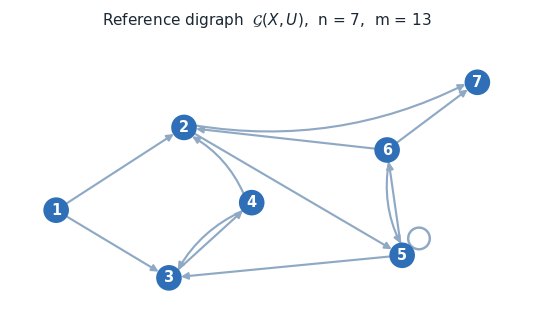

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
draw_graph(ax, POS_7, G.arcs, curved=CURVED,
           title="Reference digraph  $\\mathcal{G}(X,U)$,  n = 7,  m = 13")
plt.show()

In [7]:
A = G.adjacency_matrix()
B = G.incidence_matrix()
pointer, adjacency = G.compact_representation()

# The compact form must reproduce the successor sets exactly.
for i in range(G.n):
    assert adjacency[pointer[i]:pointer[i + 1]] == G.successors(i)

print("pointer   :", pointer)
print("adjacency :", [v + 1 for v in adjacency])
print(f"\nadjacency matrix : {A.size} cells, {A.sum()} non-zero "
      f"({100 * A.sum() / A.size:.0f}% density)")
print(f"incidence matrix : {B.size} cells")
print(f"compact form     : {len(pointer) + len(adjacency)} integers  \u2190 the sparse one")

pointer   : [0, 2, 4, 5, 7, 10, 13, 13]
adjacency : [2, 3, 5, 7, 4, 2, 3, 3, 5, 6, 2, 5, 7]

adjacency matrix : 49 cells, 13 non-zero (27% density)
incidence matrix : 91 cells
compact form     : 21 integers  ← the sparse one


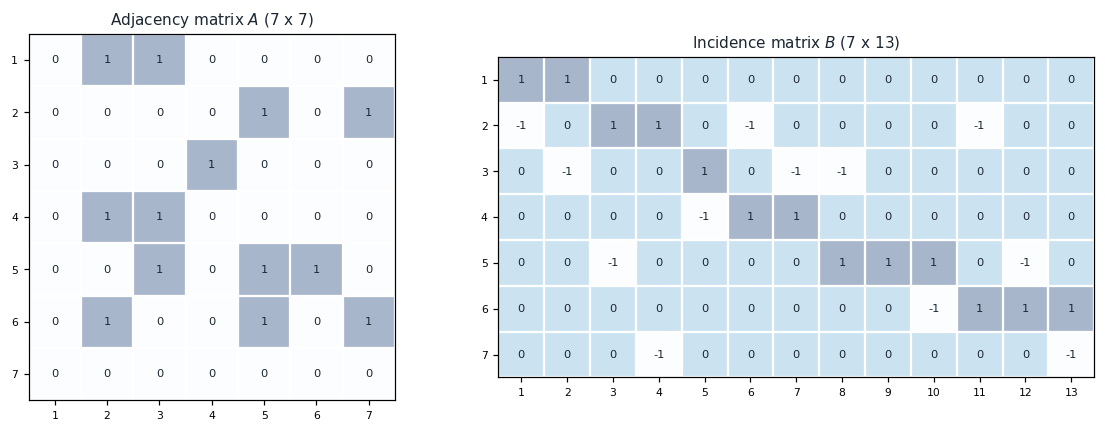

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
draw_matrix(axes[0], A, "Adjacency matrix $A$ (7 x 7)")
draw_matrix(axes[1], B, "Incidence matrix $B$ (7 x 13)")
plt.tight_layout()
plt.show()

The incidence matrix is the least practical of the three for computation, but it is
the one that generalises: its columns are exactly the constraint vectors of a network
flow linear program — the bridge from section 4 to section 5.

<a id="2"></a>
## 2. Connectivity and ranks

Three questions about structure, all answered with the same tool.

**The idea.** Replace `(+, ×)` by `(or, and)` in the matrix product, and `A^k` stops
counting walks of length `k` and starts answering *whether one exists*. Since any walk
can be taken elementary, and therefore of length at most `n − 1`, adding the identity
lets shorter walks survive the powers and the transitive closure becomes a single
expression: `(I + A)^(n−1)`.

**Strong components.** Vertices *i* and *j* are in the same component exactly when
each reaches the other, so the components are read off `R ∧ Rᵀ`. This is `O(n³)` where
Tarjan's algorithm is linear — the matrix formulation is the one being illustrated
here, and it makes the symmetry of the relation visible.

**Ranks.** Peel the sources one layer at a time. If a round finds no removable vertex,
every remaining vertex has a predecessor still in the set, which can only happen on a
circuit — so the same procedure detects circuits for free.

In [9]:
def transitive_closure(g):
    """Reachability matrix as (I + A)^(n-1) in boolean algebra."""
    M = np.eye(g.n, dtype=bool) | g.adjacency_matrix().astype(bool)
    R, powers = M.copy(), [M.copy()]
    for _ in range(g.n - 2):
        R = R @ M                      # (or, and) product on boolean arrays
        powers.append(R.copy())
    return R, powers


def strongly_connected_components(g):
    R, _ = transitive_closure(g)
    mutual = R & R.T
    seen, comps = set(), []
    for i in range(g.n):
        if i not in seen:
            comp = {j for j in range(g.n) if mutual[i, j]}
            comps.append(sorted(comp))
            seen |= comp
    return comps


def ranks(g):
    """r(x) = 0 for a source, else one more than the largest predecessor rank."""
    remaining, rank, k = set(range(g.n)), {}, 0
    while remaining:
        layer = [x for x in remaining
                 if all(p not in remaining for p in g.predecessors(x))]
        if not layer:
            raise ValueError("the graph contains at least one circuit")
        for x in layer:
            rank[x] = k
        remaining -= set(layer)
        k += 1
    return rank

In [10]:
R, powers = transitive_closure(G)
comps = strongly_connected_components(G)

print("strongly connected components:", [[v + 1 for v in c] for c in comps])
assert [[v + 1 for v in c] for c in comps] == [[1], [2, 3, 4, 5, 6], [7]]

print("BFS from 1:", [v + 1 for v in G.bfs(0)])
print("DFS from 1:", [v + 1 for v in G.dfs(0)])

try:
    ranks(G)
except ValueError as e:
    print(f"\nranks(G) -> {e}   (correct: G has circuits)")

r = ranks(DAG)
print("ranks of the circuit-free graph:", {v + 1: r[v] for v in sorted(r)})
assert [r[v] for v in range(7)] == [0, 1, 1, 2, 3, 2, 4]
assert all(r[i] < r[j] for (i, j) in DAG.arcs), "every arc must increase the rank"
print("every arc increases the rank  \u2713")

strongly connected components: [[1], [2, 3, 4, 5, 6], [7]]
BFS from 1: [1, 2, 3, 5, 7, 4, 6]
DFS from 1: [1, 2, 5, 3, 4, 6, 7]

ranks(G) -> the graph contains at least one circuit   (correct: G has circuits)
ranks of the circuit-free graph: {1: 0, 2: 1, 3: 1, 4: 2, 5: 3, 6: 2, 7: 4}
every arc increases the rank  ✓


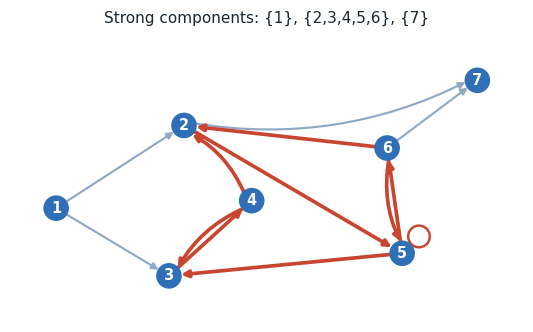

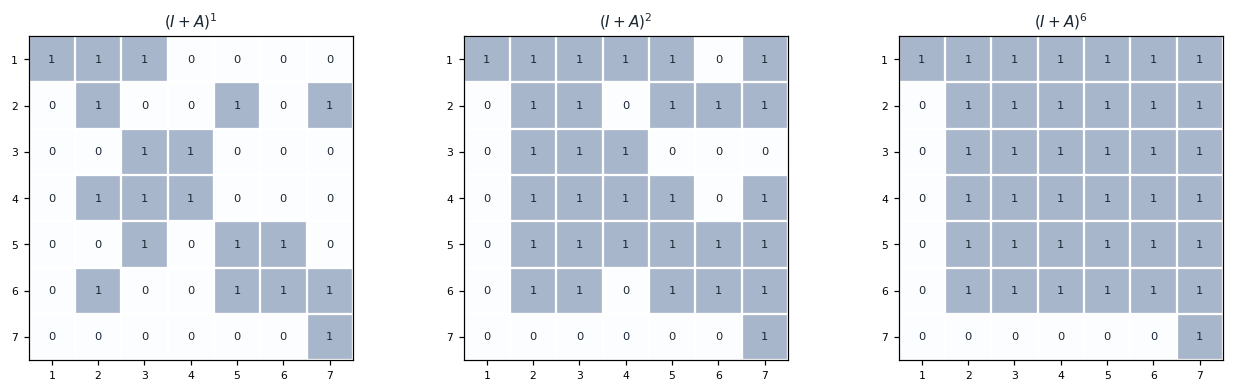

In [11]:
inside = [(i, j) for c in comps if len(c) > 1
          for (i, j) in G.arcs if i in c and j in c]

fig, ax = plt.subplots(figsize=(6, 4))
draw_graph(ax, POS_7, G.arcs, curved=CURVED, highlight=inside,
           title="Strong components: {1}, {2,3,4,5,6}, {7}")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (k, P) in zip(axes, [(1, powers[0]), (2, powers[1]), (len(powers), R)]):
    draw_matrix(ax, P.astype(int), f"$(I + A)^{{{k}}}$")
plt.tight_layout()
plt.show()

The rectangles of ones in the final matrix *are* the strong components — the block
structure is not a coincidence, it is the equivalence relation made visible.

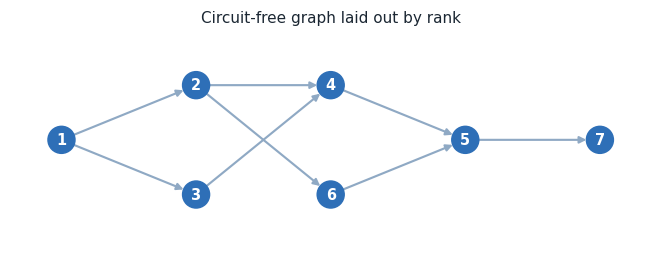

In [12]:
by_rank = {}
for v, k in r.items():
    by_rank.setdefault(k, []).append(v)
layer_pos = {v: (k * 1.6, -i * 1.3 + (len(vs) - 1) * .65)
             for k, vs in by_rank.items() for i, v in enumerate(sorted(vs))}

fig, ax = plt.subplots(figsize=(7.5, 3))
draw_graph(ax, layer_pos, DAG.arcs, title="Circuit-free graph laid out by rank")
plt.show()

<a id="3"></a>
## 3. Optimal paths

**Dijkstra.** Each vertex carries a label: *definitive*, meaning it is the value of an
optimal path, or *provisional*, meaning it is an upper bound. Each iteration promotes
the smallest provisional label, then relaxes its successors.

Non-negativity is exactly what makes that promotion valid: a label about to be frozen
cannot be improved later, because any competing route would pass through a vertex
whose label is already larger, and no arc can bring the total back down. With a
negative arc the argument collapses — so the implementation *raises* rather than
returning a plausible wrong answer.

**Floyd–Warshall.** At step `k` the matrix holds the best value using only vertices
`1..k` as intermediates, so the update is one relaxation through `k`. Negative weights
are fine; negative *circuits* are not, and they make the problem ill-posed rather than
merely hard — going round once more always improves the total. They surface as a
negative diagonal entry.

**Path reconstruction.** The usual presentation carries a matrix of pivot vertices and
rebuilds paths recursively. Storing the **next hop** instead carries the same
information, updated by `N[i,j] ← N[i,k]`, and turns reconstruction into a loop.

In [13]:
def dijkstra(g, source):
    if any(w < 0 for w in g.weight.values()):
        raise ValueError("Dijkstra requires non-negative weights; use Floyd instead")

    W = g.weight_matrix()
    lam = np.full(g.n, INF)
    lam[source] = 0.0
    pred = [None] * g.n
    for j in g.successors(source):
        lam[j], pred[j] = W[source, j], source

    definitive, history = {source}, [lam.copy()]
    while len(definitive) < g.n:
        i = min((v for v in range(g.n) if v not in definitive), key=lambda v: lam[v])
        if lam[i] == INF:
            break                                   # remaining vertices unreachable
        definitive.add(i)
        for j in g.successors(i):
            if j not in definitive and lam[i] + W[i, j] < lam[j]:
                lam[j], pred[j] = lam[i] + W[i, j], i
        history.append(lam.copy())
    return lam, pred, history


def floyd(g):
    W = g.weight_matrix().copy()
    N = np.full((g.n, g.n), -1, dtype=int)
    for (i, j) in g.arcs:
        N[i, j] = j
    np.fill_diagonal(N, np.arange(g.n))

    steps = [W.copy()]
    for k in range(g.n):
        through_k = W[:, [k]] + W[[k], :]
        better = through_k < W
        N = np.where(better, N[:, [k]], N)
        W = np.where(better, through_k, W)
        steps.append(W.copy())

    if (np.diag(W) < 0).any():
        raise ValueError("negative circuit detected: no optimal path exists")
    return W, N, steps


def path_from_pred(pred, s, t):
    path, v = [], t
    while v is not None:
        path.append(v)
        if v == s:
            return path[::-1]
        v = pred[v]
    return []


def path_from_next_hop(N, i, j):
    if N[i, j] == -1:
        return []
    path = [i]
    while i != j:
        i = N[i, j]
        path.append(i)
    return path

In [14]:
lam, pred, history = dijkstra(GW, 0)

print("Dijkstra from vertex 1\n")
print("  target   value   path")
tree = []
for t in range(1, GW.n):
    p = path_from_pred(pred, 0, t)
    print(f"    {t+1}       {lam[t]:5.0f}   " + " -> ".join(str(v + 1) for v in p))
    tree += list(zip(p, p[1:]))

assert list(lam) == [0, 7, 2, 5, 10, 14, 16], "reference labels"
print("\nlabels match the reference  \u2713")

Dijkstra from vertex 1

  target   value   path
    2           7   1 -> 3 -> 4 -> 2
    3           2   1 -> 3
    4           5   1 -> 3 -> 4
    5          10   1 -> 3 -> 4 -> 2 -> 5
    6          14   1 -> 3 -> 4 -> 2 -> 5 -> 6
    7          16   1 -> 3 -> 4 -> 2 -> 5 -> 6 -> 7

labels match the reference  ✓


Vertex 2 is the instructive one. The direct arc `1 → 2` costs 8, but the detour through
3 and 4 costs 7 — its label starts at 8 and drops before being frozen.

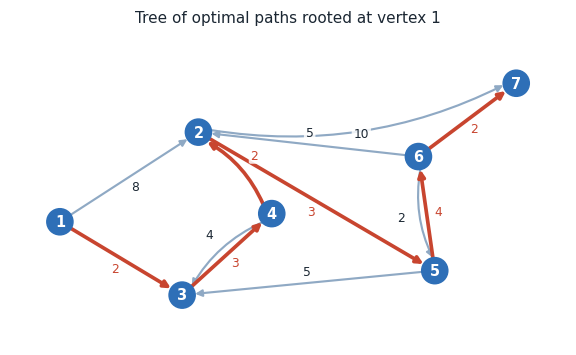

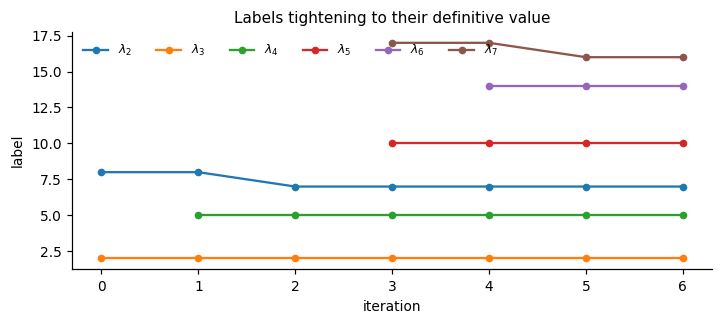

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
draw_graph(ax, POS_7, GW.arcs, curved=CURVED, highlight=tree,
           arc_labels={a: f"{GW.weight[a]:g}" for a in GW.arcs},
           title="Tree of optimal paths rooted at vertex 1")
plt.show()

H = np.array(history)
fig, ax = plt.subplots(figsize=(7.5, 2.8))
for t in range(1, GW.n):
    ax.plot(np.where(np.isfinite(H[:, t]), H[:, t], np.nan),
            marker="o", ms=4, label=f"$\\lambda_{{{t+1}}}$")
ax.set_xlabel("iteration")
ax.set_ylabel("label")
ax.set_title("Labels tightening to their definitive value")
ax.legend(ncol=6, fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [16]:
try:
    dijkstra(GN, 0)
except ValueError as e:
    print(f"dijkstra(GN, 0) -> {e}\n")

W, N, steps = floyd(GN)
reference = np.array([
    [0, 1, 2, -1, -2, 2, 0],
    [INF, 0, 2, -1, -3, 1, -1],
    [INF, -1, 0, -3, -4, 0, -2],
    [INF, 2, 4, 0, -1, 3, 1],
    [INF, 4, 5, 2, 0, 4, 2],
    [INF, 2, 3, 0, -2, 0, -2],
    [INF, INF, INF, INF, INF, INF, 0]])
assert np.array_equal(W, reference), "Floyd disagrees with the reference matrix"
print("Floyd matrix matches the reference exactly  \u2713")

# Every reconstructed path must use real arcs and sum to the announced value.
for i in range(GN.n):
    for j in range(GN.n):
        if i != j and np.isfinite(W[i, j]):
            p = path_from_next_hop(N, i, j)
            e = list(zip(p, p[1:]))
            assert all(a in GN.weight for a in e), f"phantom arc in {p}"
            assert abs(sum(GN.weight[a] for a in e) - W[i, j]) < 1e-9
print("all 40 reconstructed paths are real and correctly valued  \u2713")

best = path_from_next_hop(N, 0, 6)
print(f"\nbest 1 -> 7 : {' -> '.join(str(v+1) for v in best)}  of value {W[0,6]:g}")
print("             (compare with the direct arc 2 -> 7 of weight 10)")

dijkstra(GN, 0) -> Dijkstra requires non-negative weights; use Floyd instead

Floyd matrix matches the reference exactly  ✓
all 40 reconstructed paths are real and correctly valued  ✓

best 1 -> 7 : 1 -> 3 -> 4 -> 2 -> 5 -> 6 -> 7  of value 0
             (compare with the direct arc 2 -> 7 of weight 10)


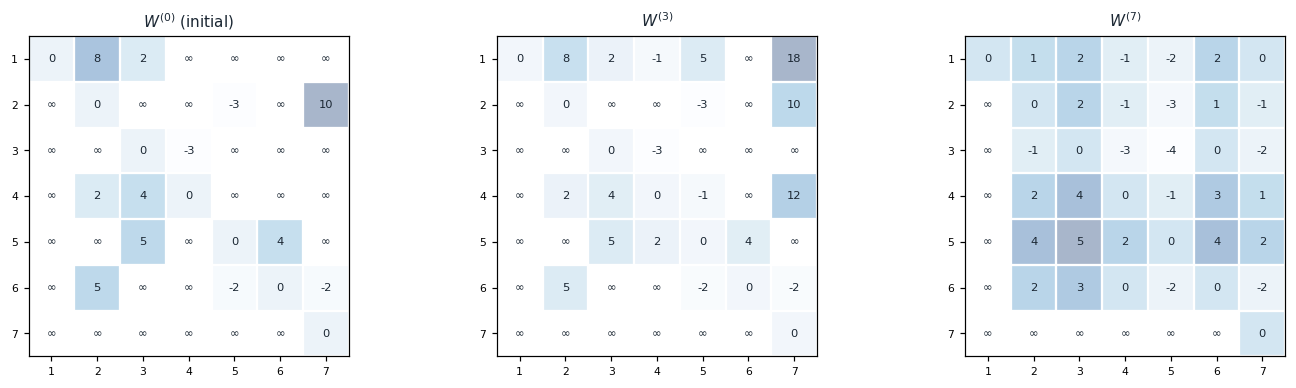

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, k in zip(axes, [0, 3, 7]):
    draw_matrix(ax, steps[k], "$W^{(0)}$ (initial)" if k == 0 else f"$W^{{({k})}}$")
plt.tight_layout()
plt.show()

The two algorithms share no code, so on the non-negative instance Floyd's first row
must equal Dijkstra's label vector. That agreement is the strongest check here.

In [18]:
lam2, _, _ = dijkstra(GW, 0)
W2, _, _ = floyd(GW)
assert np.allclose(lam2, W2[0])
print("Dijkstra and Floyd agree on the non-negative instance  \u2713")

Dijkstra and Floyd agree on the non-negative instance  ✓


<a id="4"></a>
## 4. Maximum flow and minimum cut

Each arc has a capacity. A flow stays within it and satisfies Kirchhoff's law at every
intermediate vertex. The question is how much can be pushed from source to sink.

**The residual network is the whole trick.** Every arc carrying flow gets a backward
partner of capacity equal to that flow, so a later augmenting path can *undo* an
earlier routing decision. Without it the first path chosen would be final, and the
algorithm would stop at a local optimum.

Augmenting paths are found breadth-first — the Edmonds–Karp refinement. This is not an
optimisation but a correctness requirement: with irrational capacities and a poor
choice of paths, Ford–Fulkerson can fail to terminate at all.

**The minimum cut** is read off the residual network once no augmenting path remains.
Every forward arc across the boundary is saturated and every backward arc empty, so its
capacity equals the flow *by construction* — the max-flow min-cut theorem falls out
rather than being proved separately.

In [19]:
def augmenting_path(residual, s, t):
    """Shortest path with spare capacity, breadth-first."""
    parent = [-1] * len(residual)
    parent[s] = s
    queue = deque([s])
    while queue:
        i = queue.popleft()
        for j in range(len(residual)):
            if parent[j] == -1 and residual[i, j] > 0:
                parent[j] = i
                if j == t:
                    path, v = [t], t
                    while v != s:
                        v = parent[v]
                        path.append(v)
                    return path[::-1]
                queue.append(j)
    return None


def ford_fulkerson(g, s, t):
    capacity = np.zeros((g.n, g.n))
    for (i, j) in g.arcs:
        capacity[i, j] += g.weight[(i, j)]

    residual, steps, value = capacity.copy(), [], 0.0
    while (path := augmenting_path(residual, s, t)) is not None:
        edges = list(zip(path, path[1:]))
        bottleneck = min(residual[e] for e in edges)
        for (i, j) in edges:
            residual[i, j] -= bottleneck
            residual[j, i] += bottleneck
        value += bottleneck
        steps.append((path, bottleneck))

    flow = {a: capacity[a] - residual[a] for a in g.arcs}

    # Capacity bounds and conservation, verified before returning.
    for a, f in flow.items():
        assert -1e-9 <= f <= g.weight[a] + 1e-9, f"capacity violated on {a}"
    for v in range(g.n):
        if v not in (s, t):
            into = sum(f for (i, j), f in flow.items() if j == v)
            out = sum(f for (i, j), f in flow.items() if i == v)
            assert abs(into - out) < 1e-9, f"flow not conserved at {v+1}"
    return value, flow, steps


def min_cut(g, s, t):
    value, flow, _ = ford_fulkerson(g, s, t)
    residual = np.zeros((g.n, g.n))
    for a in g.arcs:
        i, j = a
        residual[i, j] += g.weight[a] - flow[a]
        residual[j, i] += flow[a]

    reachable, queue = {s}, deque([s])
    while queue:
        i = queue.popleft()
        for j in range(g.n):
            if j not in reachable and residual[i, j] > 1e-9:
                reachable.add(j)
                queue.append(j)

    cut = [(i, j) for (i, j) in g.arcs if i in reachable and j not in reachable]
    capacity = sum(g.weight[a] for a in cut)
    assert abs(capacity - value) < 1e-9, "min cut must equal max flow"
    return sorted(reachable), cut, capacity

In [20]:
value, flow, steps = ford_fulkerson(FLOW, 0, 5)

for k, (path, b) in enumerate(steps, 1):
    print(f"  augmentation {k}: {' -> '.join(FLOW_LABELS[v] for v in path):<30} "
          f"bottleneck {b:g}")

print(f"\nmaximum flow = {value:g}\n")
for a in FLOW.arcs:
    print(f"  {FLOW_LABELS[a[0]]} -> {FLOW_LABELS[a[1]]}   {flow[a]:g} / {FLOW.weight[a]:g}")
assert value == 12

  augmentation 1: A -> B -> D -> F               bottleneck 6
  augmentation 2: A -> C -> D -> F               bottleneck 2
  augmentation 3: A -> C -> E -> F               bottleneck 3
  augmentation 4: A -> C -> D -> B -> E -> F     bottleneck 1

maximum flow = 12

  A -> B   6 / 6
  A -> C   6 / 8
  B -> D   5 / 6
  B -> E   1 / 3
  C -> D   3 / 3
  C -> E   3 / 3
  D -> F   8 / 8
  E -> F   4 / 6


The fourth path is worth reading twice. It travels **backwards** along `B → D`, undoing
one unit placed there by the first augmentation and rerouting it through `B → E`. No
greedy forward search would find it — this is the residual network earning its place.

In [21]:
side, cut, capacity = min_cut(FLOW, 0, 5)
names = "{" + ", ".join(FLOW_LABELS[v] for v in side) + "}"
print(f"minimum cut: S = {names},  capacity = {capacity:g}")
print("  arcs crossing:", ", ".join(f"{FLOW_LABELS[i]}->{FLOW_LABELS[j]}" for i, j in cut))
print(f"\nmax flow = min cut = {value:g}  \u2713")

# {A, B} is also a cut, and also an upper bound -- but not a tight one.
other = sum(FLOW.weight[(i, j)] for (i, j) in FLOW.arcs
            if i in {0, 1} and j not in {0, 1})
print(f"\nfor comparison, the cut {{A, B}} has capacity {other:g}: a valid bound, "
      "but it certifies nothing")

minimum cut: S = {A, C},  capacity = 12
  arcs crossing: A->B, C->D, C->E

max flow = min cut = 12  ✓

for comparison, the cut {A, B} has capacity 17: a valid bound, but it certifies nothing


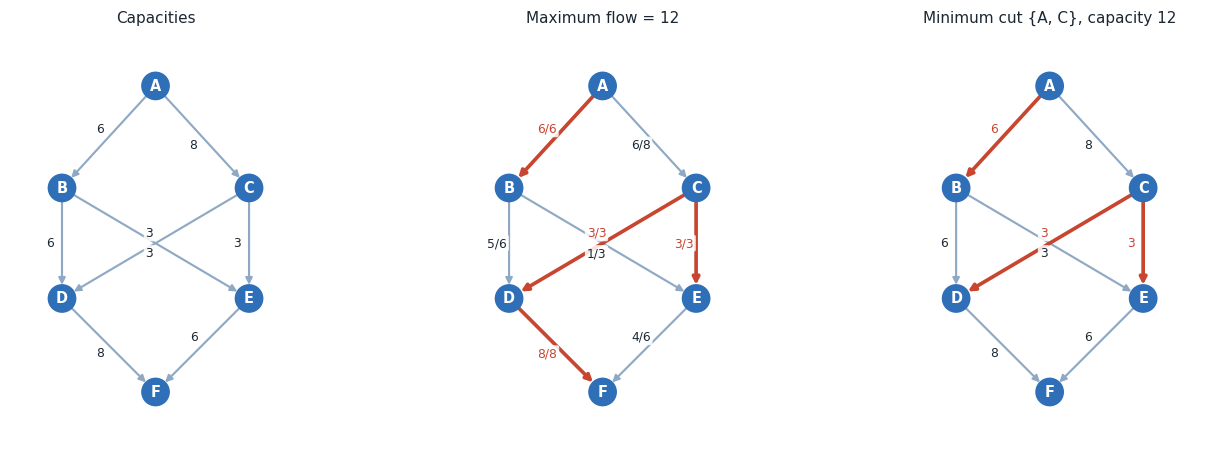

In [22]:
caps = {a: f"{FLOW.weight[a]:g}" for a in FLOW.arcs}
used = {a: f"{flow[a]:g}/{FLOW.weight[a]:g}" for a in FLOW.arcs}
saturated = [a for a in FLOW.arcs if flow[a] == FLOW.weight[a]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
draw_graph(axes[0], POS_FLOW, FLOW.arcs, FLOW_LABELS, caps, title="Capacities")
draw_graph(axes[1], POS_FLOW, FLOW.arcs, FLOW_LABELS, used, highlight=saturated,
           title=f"Maximum flow = {value:g}")
draw_graph(axes[2], POS_FLOW, FLOW.arcs, FLOW_LABELS, caps, highlight=cut,
           title=f"Minimum cut {names}, capacity {capacity:g}")
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Linear programming

**The geometry first**, because the mechanics only make sense on top of it. The
admissible set is a polyhedron — an intersection of half-spaces. The objective is
linear, so its level sets are parallel hyperplanes, and the optimum, when it exists,
is attained at a vertex. There are finitely many vertices, so the problem is finite;
but exponentially many, so enumeration is not a method.

The simplex walks from vertex to adjacent vertex, never worsening the objective, and
stops when no neighbour improves it. On a tableau:

- **standard form** — slack variables turn inequalities into equalities, and form an
  obvious first basis corresponding to the origin;
- **entering variable** — the largest positive objective coefficient (Dantzig's rule);
- **leaving variable** — the smallest positive ratio `bᵢ / aᵢⱼ`, the first constraint
  hit when moving along the chosen edge;
- **pivot** — Gauss–Jordan on that cell.

**Scope.** This assumes the slack basis is admissible (`A x ≤ b` with `b ≥ 0`), which
covers resource allocation but not programs needing a phase-I. Those raise, rather than
returning something wrong. Unboundedness is detected; cycling is capped rather than
prevented, where Bland's rule would prevent it outright.

In [23]:
class Simplex:
    """Maximise c . x subject to A x <= b, x >= 0."""

    def __init__(self, c, A, b, names=None):
        self.c, self.A, self.b = (np.asarray(v, float) for v in (c, A, b))
        self.m, self.n = self.A.shape
        if (self.b < 0).any():
            raise ValueError("negative right-hand side: the slack basis is "
                             "inadmissible and there is no phase-I here")
        self.names = list(names or [f"x{j+1}" for j in range(self.n)]) \
            + [f"e{i+1}" for i in range(self.m)]
        self.history = []

    def solve(self, max_iter=200):
        T = np.zeros((self.m + 1, self.n + self.m + 1))
        T[:self.m, :self.n] = self.A
        T[:self.m, self.n:self.n + self.m] = np.eye(self.m)
        T[:self.m, -1] = self.b
        T[-1, :self.n] = self.c
        basis = list(range(self.n, self.n + self.m))
        self.history.append(T.copy())

        for _ in range(max_iter):
            j = int(np.argmax(T[-1, :-1]))
            if T[-1, j] <= 1e-9:
                break                                          # optimal
            col, rhs = T[:-1, j], T[:-1, -1]
            ok = col > 1e-9
            if not ok.any():
                raise ValueError("unbounded: the objective grows without limit")
            i = int(np.argmin(np.where(ok, rhs / np.where(ok, col, 1), np.inf)))
            T[i] /= T[i, j]
            for r in range(T.shape[0]):
                if r != i and abs(T[r, j]) > 1e-12:
                    T[r] -= T[r, j] * T[i]
            basis[i] = j
            self.history.append(T.copy())
        else:
            raise RuntimeError("iteration limit reached (possible cycling)")

        x = np.zeros(self.n + self.m)
        for row, var in enumerate(basis):
            x[var] = T[row, -1]
        self.tableau, self.x, self.slack = T, x[:self.n], x[self.n:]
        self.value = float(-T[-1, -1])
        return self.x, self.value

    def check(self):
        assert (self.x >= -1e-9).all()
        assert (self.A @ self.x <= self.b + 1e-7).all()
        assert abs(self.c @ self.x - self.value) < 1e-7
        return True

    def report(self):
        print(f"optimum = {self.value:g}\n")
        for name, v in zip(self.names[:self.n], self.x):
            print(f"  {name} = {v:g}")
        print()
        for i, s in enumerate(self.slack):
            print(f"  constraint {i+1}: "
                  + ("saturated" if abs(s) < 1e-9 else f"{s:g} left over"))

In [24]:
c, A, b = [30, 50], [[3, 2], [1, 0], [0, 1]], [1800, 400, 600]
lp = Simplex(c, A, b, names=["x", "y"])
lp.solve()
lp.check()
lp.report()

assert lp.value == 36000 and list(lp.x) == [200, 600]
print("\nmatches the reference tableau  \u2713")

optimum = 36000

  x = 200
  y = 600

  constraint 1: saturated
  constraint 2: 200 left over
  constraint 3: saturated

matches the reference tableau  ✓


The **slack variables are the interesting output**, not the objective. Constraints 1
and 3 are saturated — those are the binding resources, and buying more of them would
raise the optimum. Constraint 2 has 200 units unused, so it is not what limits
production. That reading is the entire practical value of the method.

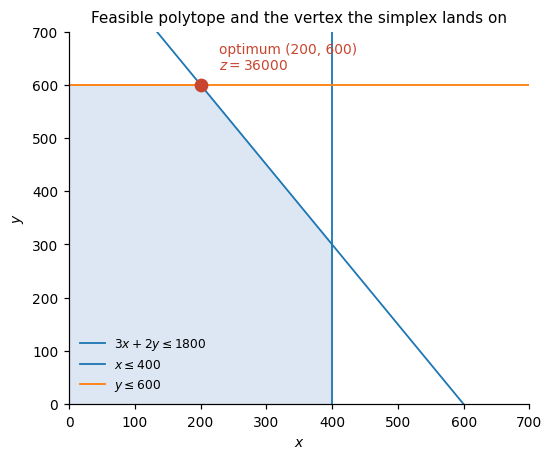

In [25]:
grid = np.linspace(0, 700, 400)
X, Y = np.meshgrid(grid, grid)
feasible = np.ones_like(X, dtype=bool)
for row, rhs in zip(A, b):
    feasible &= row[0] * X + row[1] * Y <= rhs

fig, ax = plt.subplots(figsize=(5.4, 4.4))
ax.contourf(X, Y, feasible, levels=[.5, 1.5], colors=[FACE], alpha=.16)
for row, rhs, lab in zip(A, b, ["$3x+2y \\leq 1800$", "$x \\leq 400$", "$y \\leq 600$"]):
    if row[1]:
        ax.plot(grid, (rhs - row[0] * grid) / row[1], lw=1.2, label=lab)
    else:
        ax.axvline(rhs / row[0], lw=1.2, label=lab)
ax.plot(*lp.x, "o", color=HILITE, ms=8, zorder=5)
ax.annotate(f"optimum ({lp.x[0]:g}, {lp.x[1]:g})\n$z = {lp.value:g}$", lp.x,
            textcoords="offset points", xytext=(12, 10), color=HILITE, fontsize=9)
ax.set_xlim(0, 700); ax.set_ylim(0, 700)
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("Feasible polytope and the vertex the simplex lands on")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [26]:
# A larger instance: four machines, five products.
c2 = [100, 75, 50, 25, 50]
A2 = [[4, 0, 2, 0, 4], [2, 3, 0, 0, 3], [3, 0, 1, 1, 0], [0, 5, 4, 2, 0]]
b2 = [500, 800, 700, 900]

lp2 = Simplex(c2, A2, b2, names=[f"P{j+1}" for j in range(5)])
lp2.solve()
lp2.check()
lp2.report()

try:
    from scipy.optimize import linprog
    res = linprog(-np.array(c2), A_ub=A2, b_ub=b2, bounds=[(0, None)] * 5)
    assert res.success and abs(-res.fun - lp2.value) < 1e-6
    print(f"\ncross-checked against scipy.optimize.linprog: {-res.fun:g}  \u2713")
except ImportError:
    print("\n(scipy not installed, cross-check skipped)")

optimum = 26000

  P1 = 125
  P2 = 180
  P3 = 0
  P4 = 0
  P5 = 0

  constraint 1: saturated
  constraint 2: 10 left over
  constraint 3: 325 left over
  constraint 4: saturated



cross-checked against scipy.optimize.linprog: 26000  ✓


Three of the five products are not worth making at all given the machine capacities —
an answer no amount of intuition would have produced reliably.

In [27]:
# The guards do their job rather than returning something plausible.
for label, thunk in [
    ("negative right-hand side", lambda: Simplex([1, 1], [[1, 1]], [-5])),
    ("unbounded program",        lambda: Simplex([1, 1], [[-1, 1]], [5]).solve()),
]:
    try:
        thunk()
        print(f"  {label}: NO ERROR RAISED \u2717")
    except ValueError as e:
        print(f"  {label} -> {e}")

  negative right-hand side -> negative right-hand side: the slack basis is inadmissible and there is no phase-I here
  unbounded program -> unbounded: the objective grows without limit


## What was verified

Every assertion above compares against a value known before the code was written.

| Section | Check |
|---|---|
| 1 | `Σ d⁺ = Σ d⁻ = m`; the compact form round-trips to the successor sets |
| 2 | Components `{1}, {2,3,4,5,6}, {7}`; ranks `0,1,1,2,3,2,4`; every arc increases the rank; circuits detected |
| 3 | Dijkstra labels `(0,7,2,5,10,14,16)`; the full Floyd matrix; all 40 reconstructed paths real and correctly valued; the two algorithms agree |
| 4 | Max flow 12 with conservation at every vertex; min cut `{A,C}` of capacity 12 |
| 5 | Optimum 36000 at `(200,600)`; second instance cross-checked against `scipy` |

**Where this stops.** Strong components go through the reachability matrix in `O(n³)`
rather than Tarjan's linear algorithm. Bellman–Ford — single-source and tolerant of
negative weights — is the missing middle between Dijkstra and Floyd. The simplex has no
phase-I and no anti-cycling rule.

**The thread worth pulling.** Maximum flow *is* a linear program, and its dual *is* the
minimum cut. Sections 4 and 5 are the same theorem seen from two sides, and making that
explicit — shadow prices, complementary slackness — is the natural next notebook.